# Evaluate PointNet++ VAE Checkpoints
Only computes Chamfer Distance and EMD for checkpoints starting with `simulated_data` and reports per structure type.

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from synthetic_peptides_dataset import SyntheticPeptidesDataset

NUM_FILES = 1
STRUCTURE_TYPES = ["nanotubes", "nanofibers", "micelles", "lamellar_sheets"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── load model definitions from training notebook ──────────────────────────
def load_symbols_from_notebook(nb_path, symbols):
    nb = json.loads(Path(nb_path).read_text())
    for c in nb["cells"]:
        if c.get("cell_type") != "code":
            continue
        s = "".join(c.get("source", []))
        try:
            exec(s, globals(), globals())
        except Exception:
            pass
        if all(sym in globals() for sym in symbols):
            break

load_symbols_from_notebook(
    "train_synthetic_peptides.ipynb",
    ["knn", "get_graph_feature", "PointNetPlusPlusEncoder", "AdaptivePointDecoder", "PointNetPlusPlusVAE"],
)

# ── metrics ────────────────────────────────────────────────────────────────
def cd(a, b):
    # a, b: [1, n_pts, 3]
    d = torch.cdist(a, b)
    return (d.min(2).values.mean() + d.min(1).values.mean()).item()

def emd_np(a, b, m=256):
    n = min(len(a), len(b), m)
    if n == 0:
        return float("nan")
    a = a[np.random.choice(len(a), n, replace=len(a) < n)]
    b = b[np.random.choice(len(b), n, replace=len(b) < n)]
    try:
        from scipy.optimize import linear_sum_assignment
        c = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
        i, j = linear_sum_assignment(c)
        return float(c[i, j].mean())
    except Exception:
        t1 = torch.tensor(a).float().unsqueeze(0)
        t2 = torch.tensor(b).float().unsqueeze(0)
        d = torch.cdist(t1, t2).squeeze(0)
        return float(0.5 * (d.min(1).values.mean() + d.min(0).values.mean()).item())

def compute_mmd_cov(gen_clouds, ref_clouds, n_pts=512, batch_size=64):
    """
    gen_clouds, ref_clouds: lists of np.ndarray [n, 3]
    MMD: mean over ref of min-CD to any gen (fidelity)
    COV: fraction of ref matched by at least one gen (diversity)
    """
    n = min(min(len(x) for x in gen_clouds), min(len(x) for x in ref_clouds), n_pts)

    def subsample(clouds):
        return [c[np.random.choice(len(c), n, replace=len(c) < n)] for c in clouds]

    gen = subsample(gen_clouds)
    ref = subsample(ref_clouds)
    Na, Nb = len(gen), len(ref)
    D = torch.zeros(Na, Nb)

    for i in range(0, Na, batch_size):
        a = torch.tensor(np.stack(gen[i:i+batch_size]), dtype=torch.float32)  # [bs_a, n, 3]
        for j in range(0, Nb, batch_size):
            b = torch.tensor(np.stack(ref[j:j+batch_size]), dtype=torch.float32)  # [bs_b, n, 3]
            bs_a, bs_b = len(a), len(b)
            # expand to [bs_a * bs_b, n, 3] for batched cdist
            a_exp = a.unsqueeze(1).expand(-1, bs_b, -1, -1).reshape(bs_a * bs_b, n, 3)
            b_exp = b.unsqueeze(0).expand(bs_a, -1, -1, -1).reshape(bs_a * bs_b, n, 3)
            dists = torch.cdist(a_exp, b_exp)  # [bs_a*bs_b, n, n]
            cd_vals = dists.min(2).values.mean(-1) + dists.min(1).values.mean(-1)
            D[i:i+bs_a, j:j+bs_b] = cd_vals.reshape(bs_a, bs_b)

    mmd = D.min(0).values.mean().item()          # for each ref, closest gen
    matched = D.argmin(1)                         # for each gen, closest ref
    cov = len(matched.unique()) / Nb
    return mmd, cov

# ── helpers ────────────────────────────────────────────────────────────────
LABEL_ALIASES = {
    "micelle": "micelles",
    "nanofiber": "nanofibers",
    "nanotube": "nanotubes",
    "lamellar_sheets": "lamellar_sheets",
    "random_aggregates": "random_aggregates",
}

def struct_from_run(run):
    t = run[len("simulated_data_"):].split("_")
    if len(t) == 1 and t[0].isdigit():
        return "all"
    raw = "_".join(t[:-1] if t[-1].isdigit() else t)
    return LABEL_ALIASES.get(raw, raw)

def sample_input(points, n):
    p = points.cpu().numpy()
    idx = np.random.choice(len(p), n, replace=len(p) < n)
    return torch.tensor(p[idx].T, dtype=torch.float32, device=device).unsqueeze(0)

# ── load datasets per structure ────────────────────────────────────────────
datasets = {
    st: SyntheticPeptidesDataset(
        data_path="./data/synthetic_peptides_split/test",
        structure_types=[st],
        num_files=NUM_FILES,
        target_num_points=None,
        normalize=True,
        return_peptide_ids=False,
        seed=0,
    )
    for st in STRUCTURE_TYPES
}

# ── evaluation loop ────────────────────────────────────────────────────────
rows = []

for d in sorted(Path("checkpoints").glob("simulated_data*")):
    if not d.is_dir():
        continue
    run = d.name
    ckpt = (d / "best.pth") if (d / "best.pth").exists() else (d / "latest.pth")
    if not ckpt.exists():
        continue
    st = struct_from_run(run)
    c = torch.load(ckpt, map_location=device)
    n = c.get("config", {}).get("n_points", 3000)
    model = PointNetPlusPlusVAE(latent_dim=c.get("config", {}).get("latent_dim", 128), num_points=n).to(device)
    model.load_state_dict(c["model_state_dict"]); model.eval()

    eval_datasets = datasets if st == "all" else {st: datasets[st]}

    with torch.no_grad():
        for ds_name, ds in eval_datasets.items():
            cds, emds, gen_clouds, ref_clouds = [], [], [], []
            for s in ds:
                x = sample_input(s["points"], n)
                y, _, _ = model(x)
                gt = x[0].T.cpu().numpy()
                pr = y[0].T.cpu().numpy()
                ref_clouds.append(gt)
                gen_clouds.append(pr)
                cds.append(cd(y[0].T.unsqueeze(0), x[0].T.unsqueeze(0)))
                emds.append(emd_np(pr, gt))
            mmd, cov = compute_mmd_cov(gen_clouds, ref_clouds)
            rows.append({
                "structure": ds_name,
                "run": run.replace("simulated_data", "vae"),
                "trained_on": st,
                "N": len(cds),
                "Chamfer": float(np.nanmean(cds)),
                "EMD": float(np.nanmean(emds)),
                "MMD": mmd,
                "COV": cov,
            })

# ── print one table per structure ──────────────────────────────────────────
df = pd.DataFrame(rows)
for st in STRUCTURE_TYPES:
    sub = df[df["structure"] == st].sort_values("run").reset_index(drop=True)
    print(f"\n{'='*70}")
    print(f"Structure: {st}")
    print('='*70)
    print(sub[["run", "trained_on", "N", "Chamfer", "EMD", "MMD", "COV"]].to_string(index=False))


Device: cuda
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/150
Dataset ready: 1 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanofibers
Selected files per structure:
  nanofibers: 1/150
Dataset ready: 1 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: micelles
Selected files per structure:
  micelles: 1/150
Dataset ready: 1 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: lamellar_sheets
Selected files per structure:
  lamellar_sheets: 1/150
Dataset ready: 1 files, target_points=None, normalize=True


/tmp/ipykernel_725379/2116816499.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c = torch.load(ckpt, map_location=device)



Structure: nanotubes
             run trained_on  N  Chamfer      EMD      MMD  COV
        vae_1000        all  1 0.052667 0.072763 0.076522  1.0
        vae_2000        all  1 0.054214 0.073914 0.077130  1.0
         vae_300        all  1 0.102633 0.114021 0.129459  1.0
vae_nanotube_300  nanotubes  1 0.045341 0.070115 0.066735  1.0

Structure: nanofibers
              run trained_on  N  Chamfer      EMD      MMD  COV
         vae_1000        all  1 0.043027 0.059544 0.060731  1.0
         vae_2000        all  1 0.042047 0.054914 0.061407  1.0
          vae_300        all  1 0.049512 0.074697 0.067638  1.0
vae_nanofiber_300 nanofibers  1 0.042504 0.062098 0.065805  1.0

Structure: micelles
            run trained_on  N  Chamfer      EMD      MMD  COV
       vae_1000        all  1 0.053742 0.086772 0.083684  1.0
       vae_2000        all  1 0.052617 0.089502 0.079056  1.0
        vae_300        all  1 0.063781 0.082344 0.090286  1.0
vae_micelle_300   micelles  1 0.052725 0.119470 0.0

In [13]:
# ── MMD / COV: models trained on ALL structures (vae_300, vae_1000, vae_2000) ──
# Generates N_GEN samples from z ~ N(0,1) per model and compares to each
# structure's reference set.

# ── Eval 1: models trained on ALL classes ─────────────────────────────────
# Question: do generated samples resemble each structure type?
# Method: sample z ~ N(0,1), generate, compare to each structure's ref set.
# Low MMD = generated samples are close to that structure.
# High COV = generated samples cover the variety of that structure.

ALL_RUNS = ["simulated_data_300", "simulated_data_1000", "simulated_data_2000"]
N_GEN = 150
rows = []

datasets = {
    st: SyntheticPeptidesDataset(
        data_path="./data/synthetic_peptides_split/test",
        structure_types=[st],
        num_files=NUM_FILES,
        target_num_points=None,
        normalize=True,
        return_peptide_ids=False,
        seed=0,
    )
    for st in STRUCTURE_TYPES
}

for run_name in ALL_RUNS:
    d = Path("checkpoints") / run_name
    ckpt = (d / "best.pth") if (d / "best.pth").exists() else (d / "latest.pth")
    if not ckpt.exists():
        continue

    c = torch.load(ckpt, map_location=device)
    cfg = c.get("config", {})
    latent_dim = cfg.get("latent_dim", 128)
    n_pts = cfg.get("n_points", 3000)

    model = PointNetPlusPlusVAE(latent_dim=latent_dim, num_points=n_pts).to(device)
    model.load_state_dict(c["model_state_dict"])
    model.eval()

    with torch.no_grad():
        z = torch.randn(N_GEN, latent_dim, device=device)
        gen_pts = model.generate(z, num_points=n_pts)
        gen_clouds = [gen_pts[i].T.cpu().numpy() for i in range(N_GEN)]

    for st in STRUCTURE_TYPES:
        ref_clouds = [
            datasets[st][j]["points"].cpu().numpy()[
                np.random.choice(len(datasets[st][j]["points"]), n_pts,
                                 replace=len(datasets[st][j]["points"]) < n_pts)
            ]
            for j in range(len(datasets[st]))
        ]
        mmd, cov = compute_mmd_cov(gen_clouds, ref_clouds)
        rows.append({"model": run_name.replace("simulated_data", "vae"),
                     "structure": st, "MMD": mmd, "COV": cov})

df_all = pd.DataFrame(rows)
pivot_mmd = df_all.pivot(index="structure", columns="model", values="MMD").round(6)
pivot_cov = df_all.pivot(index="structure", columns="model", values="COV").round(4)
print("=== MMD (lower → generated samples are closer to that structure) ===")
print(pivot_mmd.to_string())
print("\n=== COV (higher → generated samples cover more of that structure) ===")
print(pivot_cov.to_string())


Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanotubes
Selected files per structure:
  nanotubes: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanofibers
Selected files per structure:
  nanofibers: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: micelles
Selected files per structure:
  micelles: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: lamellar_sheets
Selected files per structure:
  lamellar_sheets: 150/150
Dataset ready: 150 files, target_points=None, normalize=True


/tmp/ipykernel_725379/422189778.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c = torch.load(ckpt, map_location=device)


=== MMD (lower → generated samples are closer to that structure) ===
model            vae_1000  vae_2000   vae_300
structure                                    
lamellar_sheets  0.133847  0.131822  0.134011
micelles         0.105827  0.119639  0.137366
nanofibers       0.090568  0.088111  0.100142
nanotubes        0.108606  0.103838  0.115992

=== COV (higher → generated samples cover more of that structure) ===
model            vae_1000  vae_2000  vae_300
structure                                   
lamellar_sheets    0.1533    0.1600   0.1400
micelles           0.0467    0.0533   0.0400
nanofibers         0.3133    0.3800   0.2200
nanotubes          0.2800    0.3200   0.1933


In [14]:
# ── Eval 2: models trained on a SINGLE structure class ────────────────────
# Question: does the model capture the variety within its structure?
# Method: sample z ~ N(0,1), generate, compare to that structure's ref set.
# High COV = model generates diverse examples (not mode-collapsed).
# Low MMD  = generated samples are faithful to the real distribution.

SPECIFIC_RUNS = {
    "simulated_data_nanotube_300":        "nanotubes",
    "simulated_data_nanofiber_300":       "nanofibers",
    "simulated_data_micelle_300":         "micelles",
    "simulated_data_lamellar_sheets_300": "lamellar_sheets",
}
N_GEN = 150
rows = []

datasets = {
    st: SyntheticPeptidesDataset(
        data_path="./data/synthetic_peptides_split/test",
        structure_types=[st],
        num_files=NUM_FILES,
        target_num_points=None,
        normalize=True,
        return_peptide_ids=False,
        seed=0,
    )
    for st in STRUCTURE_TYPES
}

for run_name, st in SPECIFIC_RUNS.items():
    d = Path("checkpoints") / run_name
    ckpt = (d / "best.pth") if (d / "best.pth").exists() else (d / "latest.pth")
    if not ckpt.exists():
        print(f"Skipping {run_name}")
        continue

    c = torch.load(ckpt, map_location=device)
    cfg = c.get("config", {})
    latent_dim = cfg.get("latent_dim", 128)
    n_pts = cfg.get("n_points", 3000)

    model = PointNetPlusPlusVAE(latent_dim=latent_dim, num_points=n_pts).to(device)
    model.load_state_dict(c["model_state_dict"])
    model.eval()

    ref_clouds = [
        datasets[st][j]["points"].cpu().numpy()[
            np.random.choice(len(datasets[st][j]["points"]), n_pts,
                             replace=len(datasets[st][j]["points"]) < n_pts)
        ]
        for j in range(len(datasets[st]))
    ]

    with torch.no_grad():
        z = torch.randn(N_GEN, latent_dim, device=device)
        gen_pts = model.generate(z, num_points=n_pts)
        gen_clouds = [gen_pts[i].T.cpu().numpy() for i in range(N_GEN)]

    mmd, cov = compute_mmd_cov(gen_clouds, ref_clouds)
    rows.append({"model": run_name.replace("simulated_data", "vae"),
                 "structure": st, "MMD": mmd, "COV": cov})

df_spec = pd.DataFrame(rows)
print("=== MMD (lower → faithful to structure distribution) ===")
print("=== COV (higher → more variety within structure)      ===")
print(df_spec[["model", "structure", "MMD", "COV"]].to_string(index=False))


Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanotubes
Selected files per structure:
  nanotubes: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: nanofibers
Selected files per structure:
  nanofibers: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: micelles
Selected files per structure:
  micelles: 150/150
Dataset ready: 150 files, target_points=None, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/test
Structure types: lamellar_sheets
Selected files per structure:
  lamellar_sheets: 150/150
Dataset ready: 150 files, target_points=None, normalize=True


/tmp/ipykernel_725379/1207021687.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c = torch.load(ckpt, map_location=device)


=== MMD (lower → faithful to structure distribution) ===
=== COV (higher → more variety within structure)      ===
                  model       structure      MMD      COV
       vae_nanotube_300       nanotubes 0.102930 0.293333
      vae_nanofiber_300      nanofibers 0.089490 0.233333
        vae_micelle_300        micelles 0.084866 0.240000
vae_lamellar_sheets_300 lamellar_sheets 0.125915 0.353333


# Occupancy Unconditional Setup I (seperate training per class)

In [2]:
# ── ONet imports (loaded from training notebook) ───────────────────────────

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from synthetic_peptides_dataset import SyntheticPeptidesDataset

NUM_FILES = 150
STRUCTURE_TYPES = ["nanotubes", "nanofibers", "micelles", "lamellar_sheets"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── load model definitions from training notebook ──────────────────────────
def load_symbols_from_notebook(nb_path, symbols):
    nb = json.loads(Path(nb_path).read_text())
    for c in nb["cells"]:
        if c.get("cell_type") != "code":
            continue
        s = "".join(c.get("source", []))
        try:
            exec(s, globals(), globals())
        except Exception:
            pass
        if all(sym in globals() for sym in symbols):
            break

import sys
from pathlib import Path
from torch import distributions as dist

globals().pop("PeptideDataset", None)

onet_root = Path.cwd() / "occupancy_networks"
if str(onet_root) not in sys.path:
    sys.path.insert(0, str(onet_root))

load_symbols_from_notebook(
    "occupancy_networks_peptides.ipynb",
    ["OccupancyNetwork", "Decoder", "LatentEncoder", "PeptideDataset"],
)

# ── test datasets per structure ────────────────────────────────────────────
ONET_STRUCTURE_TYPES = ["nanotubes", "nanofibers", "micelles", "lamellar_sheets"]
NUM_TEST_FILES = 150
OCC_THRESHOLD = 0.5

onet_test_datasets = {
    st: PeptideDataset(
        data_path="./data/synthetic_peptides_split/test",
        num_files=NUM_TEST_FILES,
        structure_types=[st],
        occupancy_threshold=0.01,
        num_query_points=6000,
        seed=0,
    )
    for st in ONET_STRUCTURE_TYPES
}

# ── helpers ────────────────────────────────────────────────────────────────
def struct_from_onet_run(run):
    # "onet_peptides_uncond_nanotubes_300" -> "nanotubes"
    rest = run[len("onet_peptides_uncond_"):]   # "nanotubes_300"
    parts = rest.split("_")
    return "_".join(parts[:-1]) if parts[-1].isdigit() else rest

def build_onet_model(cfg, device):
    z_dim   = cfg.get("z_dim", 128)
    h_size  = cfg.get("decoder_hidden_size", 256)
    decoder = Decoder(dim=3, z_dim=z_dim, c_dim=0, hidden_size=h_size, leaky=False)
    latent_enc = LatentEncoder(z_dim=z_dim, c_dim=0, dim=3, leaky=False)
    p0_z = dist.Normal(
        torch.zeros(z_dim, device=device),
        torch.ones(z_dim, device=device),
    )
    return OccupancyNetwork(
        decoder=decoder, encoder=None, encoder_latent=latent_enc,
        p0_z=p0_z, device=device,
    ).to(device)

# ── metric functions ───────────────────────────────────────────────────────
def volumetric_iou(pred, gt, thr=0.5):
    p, g = pred >= thr, gt >= thr
    inter, union = (p & g).sum(), (p | g).sum()
    return float(inter / union) if union > 0 else float("nan")

def f1_score_occ(pred, gt, thr=0.5):
    p, g = pred >= thr, gt >= thr
    tp, fp, fn = (p & g).sum(), (p & ~g).sum(), (~p & g).sum()
    prec   = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
    f1     = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0
    return prec, recall, f1

def occ_to_cloud(qp, pred, thr=0.5):
    mask = pred >= thr
    if mask.sum() == 0:
        mask = np.argsort(pred)[-max(1, int(0.05 * len(pred))):]
        return qp[mask]
    return qp[mask]

def compute_mmd_cov_occ(gen_clouds, ref_clouds, n_pts=512, batch_size=32):
    def sub(clouds, n):
        return [c[np.random.choice(len(c), n, replace=len(c) < n)] for c in clouds]
    n = min(min(len(c) for c in gen_clouds), min(len(c) for c in ref_clouds), n_pts)
    gen, ref = sub(gen_clouds, n), sub(ref_clouds, n)
    Na, Nb = len(gen), len(ref)
    D = torch.zeros(Na, Nb)
    for i in range(0, Na, batch_size):
        a = torch.tensor(np.stack(gen[i:i+batch_size]), dtype=torch.float32)
        for j in range(0, Nb, batch_size):
            b = torch.tensor(np.stack(ref[j:j+batch_size]), dtype=torch.float32)
            bs_a, bs_b = len(a), len(b)
            a_e = a.unsqueeze(1).expand(-1,bs_b,-1,-1).reshape(bs_a*bs_b,n,3)
            b_e = b.unsqueeze(0).expand(bs_a,-1,-1,-1).reshape(bs_a*bs_b,n,3)
            dists = torch.cdist(a_e, b_e)
            cd_vals = dists.min(2).values.mean(-1) + dists.min(1).values.mean(-1)
            D[i:i+bs_a, j:j+bs_b] = cd_vals.reshape(bs_a, bs_b)
    mmd = D.min(0).values.mean().item()
    cov = len(D.argmin(1).unique()) / Nb
    return mmd, cov

# ── evaluation loop ────────────────────────────────────────────────────────
onet_rows = []

for d in sorted(Path("checkpoints").glob("onet_peptides_uncond*")):
    if not d.is_dir():
        continue
    run  = d.name
    ckpt = (d / "best.pth") if (d / "best.pth").exists() else (d / "latest.pth")
    if not ckpt.exists():
        continue

    st  = struct_from_onet_run(run)
    c   = torch.load(ckpt, map_location=device)
    cfg = c.get("config", {})

    model = build_onet_model(cfg, device)
    model.load_state_dict(c["model_state_dict"])
    model.eval()

    eval_datasets = onet_test_datasets if st == "all" else {st: onet_test_datasets[st]}

    with torch.no_grad():
        for ds_name, ds in eval_datasets.items():
            ious, f1s, gen_clouds, ref_clouds = [], [], [], []
            for i in range(len(ds)):
                sample = ds[i]
                query  = sample["query_points"].unsqueeze(0).to(device)
                occ_gt = sample["occupancy"].unsqueeze(0).to(device)
                c_in   = torch.empty(1, 0, device=device)

                # ── IoU / F1: reconstruction (posterior z) ────────────
                q_z  = model.infer_z(query, occ_gt, c_in)
                z    = q_z.rsample()
                pred = model.decode(query, z, c_in).probs

                pred_np = pred.squeeze().cpu().numpy()
                gt_np   = occ_gt.squeeze().cpu().numpy()
                qp_np   = query.squeeze().cpu().numpy()

                ious.append(volumetric_iou(pred_np, gt_np, OCC_THRESHOLD))
                _, _, f1 = f1_score_occ(pred_np, gt_np, OCC_THRESHOLD)
                f1s.append(f1)

                # ── MMD / COV: generation (prior z, random queries) ───
                z_gen     = model.p0_z.sample([1])
                query_gen = torch.rand(1, query.shape[1], 3, device=device) - 0.5
                pred_gen  = model.decode(query_gen, z_gen, c_in).probs

                ref_clouds.append(occ_to_cloud(qp_np,                          gt_np,                             OCC_THRESHOLD))
                gen_clouds.append(occ_to_cloud(query_gen.squeeze().cpu().numpy(), pred_gen.squeeze().cpu().numpy(), OCC_THRESHOLD))

            mmd, cov = compute_mmd_cov_occ(gen_clouds, ref_clouds)
            onet_rows.append({
                "run":       run,
                "structure": ds_name,
                "N":         len(ious),
                "IoU":       float(np.nanmean(ious)),
                "F1":        float(np.nanmean(f1s)),
                "MMD":       mmd,
                "COV":       cov,
            })

# ── print results ──────────────────────────────────────────────────────────
onet_df = pd.DataFrame(onet_rows)
for st in ONET_STRUCTURE_TYPES:
    sub = onet_df[onet_df["structure"] == st].sort_values("run").reset_index(drop=True)
    if sub.empty:
        continue
    print(f"\n{'='*70}")
    print(f"Structure: {st}")
    print("="*70)
    print(sub[["run", "N", "IoU", "F1", "MMD", "COV"]].to_string(index=False))


Device: cuda
PyTorch version: 2.4.1
CUDA available: True
CUDA version: 12.0
GPU: NVIDIA GeForce RTX 2080 Ti
✓ ONet implementation imported from occupancy_networks folder
Device: cuda
Run name: onet_peptides_uncond_nanotubes_300
Config: {
  "run_name": "onet_peptides_uncond_nanotubes_300",
  "train_data_path": "./data/synthetic_peptides_split/train",
  "val_data_path": "./data/synthetic_peptides_split/val",
  "test_data_path": "./data/synthetic_peptides_split/test",
  "grid_size": 64,
  "num_query_points": 6000,
  "occupancy_threshold": 0.01,
  "train_num_files": 300,
  "val_num_files": 64,
  "z_dim": 128,
  "decoder_hidden_size": 256,
  "batch_size": 16,
  "learning_rate": 0.0002,
  "epochs": 2000,
  "save_every": 10,
  "val_interval": 10
}
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Selected files per structure:
  nanotubes: 300/700
Dataset ready: 300 files, target_points=None, normalize=True
Peptide dataset ready: 300 files, grid=64

/tmp/ipykernel_725379/864473122.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c   = torch.load(ckpt, map_location=device)



Structure: nanotubes
                               run   N      IoU       F1      MMD  COV
onet_peptides_uncond_nanotubes_300 150 0.841005 0.911895 0.130383 0.34

Structure: nanofibers
                                run   N      IoU    F1      MMD  COV
onet_peptides_uncond_nanofibers_300 150 0.855737 0.921 0.108805 0.24

Structure: micelles
                              run   N      IoU       F1     MMD  COV
onet_peptides_uncond_micelles_300 150 0.745372 0.853693 0.10514 0.42

Structure: lamellar_sheets
                                     run   N      IoU       F1      MMD      COV
onet_peptides_uncond_lamellar_sheets_300 150 0.676358 0.804761 0.127554 0.346667


In [ ]:
# ── Conditional ONet imports ───────────────────────────────────────────────
# Load ResnetPointnet, DecoderCBatchNorm, and the conditional PeptideDataset
# (which adds a 'pointcloud' field — superset of the unconditional one)
# Remove old PeptideDataset so load_symbols_from_notebook re-defines it from the conditional notebook
globals().pop("PeptideDataset", None)

load_symbols_from_notebook(
    "occupancy_networks_peptides_conditional.ipynb",
    ["ResnetPointnet", "DecoderCBatchNorm", "PeptideDataset"],
)
PeptideDatasetCond = PeptideDataset

ONET_STRUCTURE_TYPES = ["nanotubes", "nanofibers", "micelles", "lamellar_sheets", "random_aggregates"]

NUM_TEST_FILES = 150

# ── test datasets per structure (conditional version needs pointcloud field) ─
COND_POINTCLOUD_N = 3000

cond_test_datasets = {
    st: PeptideDatasetCond(
        data_path="./data/synthetic_peptides_split/test",
        num_files=NUM_TEST_FILES,
        structure_types=[st],
        occupancy_threshold=0.01,
        num_query_points=6000,
        pointcloud_n=COND_POINTCLOUD_N,
        seed=0,
    )
    for st in ONET_STRUCTURE_TYPES
}

# ── model builder ──────────────────────────────────────────────────────────
def build_cond_onet_model(cfg, device):
    c_dim    = cfg.get("c_dim", 128)
    h_size   = cfg.get("decoder_hidden_size", 256)
    enc_hdim = cfg.get("encoder_hidden_dim", 128)
    encoder  = ResnetPointnet(c_dim=c_dim, dim=3, hidden_dim=enc_hdim)
    decoder  = DecoderCBatchNorm(dim=3, z_dim=0, c_dim=c_dim, hidden_size=h_size, leaky=False)
    p0_z     = dist.Normal(torch.zeros(0, device=device), torch.ones(0, device=device))
    return OccupancyNetwork(
        decoder=decoder, encoder=encoder, encoder_latent=None,
        p0_z=p0_z, device=device,
    ).to(device)

# ── evaluation loop ────────────────────────────────────────────────────────
cond_rows = []

for d in sorted(Path("checkpoints").glob("onet_peptides_pointcloud_conditional*")):
    if not d.is_dir():
        continue
    run  = d.name
    ckpt = (d / "best.pth") if (d / "best.pth").exists() else (d / "latest.pth")
    if not ckpt.exists():
        continue

    c_ckpt = torch.load(ckpt, map_location=device)
    cfg    = c_ckpt.get("config", {})

    model_cond = build_cond_onet_model(cfg, device)
    model_cond.load_state_dict(c_ckpt["model_state_dict"])
    model_cond.eval()

    with torch.no_grad():
        for ds_name, ds in cond_test_datasets.items():
            ious, f1s, gen_clouds, ref_clouds = [], [], [], []
            for i in range(len(ds)):
                sample     = ds[i]
                pointcloud = sample["pointcloud"].unsqueeze(0).to(device)   # [1, pointcloud_n, 3]
                query      = sample["query_points"].unsqueeze(0).to(device) # [1, N, 3]
                occ_gt     = sample["occupancy"].unsqueeze(0).to(device)    # [1, N]

                c_enc  = model_cond.encode_inputs(pointcloud)
                z_empty = torch.empty(1, 0, device=device)
                pred   = model_cond.decode(query, z_empty, c_enc).probs

                pred_np = pred.squeeze().cpu().numpy()
                gt_np   = occ_gt.squeeze().cpu().numpy()
                qp_np   = query.squeeze().cpu().numpy()

                ious.append(volumetric_iou(pred_np, gt_np, OCC_THRESHOLD))
                _, _, f1 = f1_score_occ(pred_np, gt_np, OCC_THRESHOLD)
                f1s.append(f1)

            cond_rows.append({
                "run":       run,
                "structure": ds_name,
                "N":         len(ious),
                "IoU":       float(np.nanmean(ious)),
                "F1":        float(np.nanmean(f1s)),
            })




PyTorch version: 2.4.1
CUDA available: True
CUDA version: 12.0
GPU: NVIDIA GeForce RTX 2080 Ti
✓ ONet implementation imported from occupancy_networks folder
Device: cuda
Run name: onet_peptides_pointcloud_conditional_1000
Config: {
  "run_name": "onet_peptides_pointcloud_conditional_1000",
  "train_data_path": "./data/synthetic_peptides_split/train",
  "val_data_path": "./data/synthetic_peptides_split/val",
  "test_data_path": "./data/synthetic_peptides_split/test",
  "grid_size": 64,
  "num_query_points": 6000,
  "occupancy_threshold": 0.01,
  "train_num_files": 1000,
  "val_num_files": 213,
  "pointcloud_n": 3000,
  "z_dim": 0,
  "c_dim": 128,
  "encoder_hidden_dim": 128,
  "decoder_hidden_size": 256,
  "batch_size": 32,
  "learning_rate": 0.0002,
  "epochs": 2000,
  "save_every": 10,
  "val_interval": 10
}
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Selected files per struct

/tmp/ipykernel_711920/851667594.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c_ckpt = torch.load(ckpt, map_location=device)



Structure: nanotubes


KeyError: "['MMD', 'COV'] not in index"

In [33]:
# ── print results ──────────────────────────────────────────────────────────
cond_df = pd.DataFrame(cond_rows)
for st in ONET_STRUCTURE_TYPES:
    sub = cond_df[cond_df["structure"] == st].sort_values("run").reset_index(drop=True)
    if sub.empty:
        continue
    print(f"\n{'='*70}")
    print(f"Structure: {st}")
    print("="*70)
    print(sub[["run", "N", "IoU", "F1"]].to_string(index=False))


Structure: nanotubes
                                      run   N      IoU       F1
onet_peptides_pointcloud_conditional_1000 150 0.831898 0.905659
onet_peptides_pointcloud_conditional_2000 150 0.845881 0.914703
 onet_peptides_pointcloud_conditional_300 150 0.805728 0.889824

Structure: nanofibers
                                      run   N      IoU       F1
onet_peptides_pointcloud_conditional_1000 150 0.859124 0.922490
onet_peptides_pointcloud_conditional_2000 150 0.856854 0.920761
 onet_peptides_pointcloud_conditional_300 150 0.829826 0.904470

Structure: micelles
                                      run   N      IoU       F1
onet_peptides_pointcloud_conditional_1000 150 0.718809 0.836033
onet_peptides_pointcloud_conditional_2000 150 0.730336 0.843676
 onet_peptides_pointcloud_conditional_300 150 0.726195 0.841161

Structure: lamellar_sheets
                                      run   N      IoU       F1
onet_peptides_pointcloud_conditional_1000 150 0.649096 0.785398
onet_pepti

In [19]:
import plotly.graph_objects as go

# ── reload VAE with num_points=3000 for visualization ─────────────────────
VIS_PTS = 10000

vae_ckpt_path = Path("checkpoints/simulated_data_2000")
ckpt = (vae_ckpt_path / "best.pth") if (vae_ckpt_path / "best.pth").exists() else (vae_ckpt_path / "latest.pth")
c = torch.load(ckpt, map_location=device)

vae_model_vis = PointNetPlusPlusVAE(
    latent_dim=c.get("config", {}).get("latent_dim", 128),
    num_points=VIS_PTS,     # override to 3000
).to(device)
vae_model_vis.load_state_dict(c["model_state_dict"])
vae_model_vis.eval()
print(f"VAE loaded with num_points={VIS_PTS}")

def vis_subsample(pts, n=VIS_N_PTS):
    idx = np.random.choice(len(pts), min(n, len(pts)), replace=False)
    return pts[idx]

# ── 1. instantiate datasets ────────────────────────────────────────────────
vis_vae_ds = {
    st: SyntheticPeptidesDataset(
        data_path="./data/synthetic_peptides_vis",
        structure_types=[st], num_files=1,
        normalize=True, return_peptide_ids=False, seed=0,
    )
    for st in ONET_STRUCTURE_TYPES
}

vis_onet_ds = {
    st: PeptideDatasetCond(
        data_path="./data/synthetic_peptides_vis",
        num_files=1, structure_types=[st],
        occupancy_threshold=0.01, num_query_points=20000,
        pointcloud_n=3000, seed=0,
    )
    for st in ONET_STRUCTURE_TYPES
}

# ── 2. GT: actual centroids ────────────────────────────────────────────────
gt_clouds = {}
for st in ONET_STRUCTURE_TYPES:
    centroids, _ = vis_onet_ds[st].get_centroid_points(0)
    gt_clouds[st] = vis_subsample(centroids)
    print(f"GT [{st}]: {len(centroids)} centroids")

# ── 3. VAE reconstruction ──────────────────────────────────────────────────
vae_clouds = {}
for st in ONET_STRUCTURE_TYPES:
    s = vis_vae_ds[st][0]
    x = sample_input(s["points"], VIS_PTS)
    with torch.no_grad():
        y, _, _ = vae_model_vis(x, num_points=VIS_PTS)
    vae_clouds[st] = vis_subsample(y[0].T.cpu().numpy())
    print(f"VAE [{st}]: input {VIS_PTS} pts → reconstructed {y.shape[-1]} pts")

# ── 4. ONet conditional reconstruction ────────────────────────────────────
onet_clouds = {}
for st in ONET_STRUCTURE_TYPES:
    s = vis_onet_ds[st][0]
    pc = s["pointcloud"].unsqueeze(0).to(device)
    qp = s["query_points"].unsqueeze(0).to(device)
    with torch.no_grad():
        c_enc   = model_cond_2000.encode_inputs(pc)
        z_empty = torch.empty(1, 0, device=device)
        pred    = model_cond_2000.decode(qp, z_empty, c_enc).probs
    cloud = occ_to_cloud(qp.squeeze().cpu().numpy(), pred.squeeze().cpu().numpy(), OCC_THRESHOLD)
    onet_clouds[st] = vis_subsample(cloud)
    print(f"ONet [{st}]: {len(cloud)} occupied pts / {qp.shape[1]} query pts")

# ── 5. plot: 3 rows (GT / VAE / ONet) x 4 cols (structures) ───────────────
row_data   = [gt_clouds, vae_clouds, onet_clouds]
row_labels = ["Ground Truth", "VAE", "ONet Cond"]
colors     = ["royalblue", "mediumseagreen", "tomato"]
n_rows, n_cols = 3, 4
PAD = 0.005

fig = go.Figure()

for row_idx, (clouds, color, label) in enumerate(zip(row_data, colors, row_labels)):
    for col_idx, st in enumerate(ONET_STRUCTURE_TYPES):
        pts = clouds[st]
        scene_num = row_idx * n_cols + col_idx + 1
        scene_key = "scene" if scene_num == 1 else f"scene{scene_num}"

        col_lo = col_idx / n_cols + PAD
        col_hi = (col_idx + 1) / n_cols - PAD
        row_lo = (n_rows - row_idx - 1) / n_rows + PAD
        row_hi = (n_rows - row_idx) / n_rows - PAD

        fig.add_trace(go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            mode="markers",
            marker=dict(size=1.5, color=color, opacity=0.7),
            showlegend=(col_idx == 3 and row_idx == 3),
            name=label,
            scene=scene_key,
        ))
        fig.update_layout(**{scene_key: dict(
            domain=dict(x=[col_lo, col_hi], y=[row_lo, row_hi]),
            xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
            aspectmode="data",
        )})

annotations = []
for col_idx, st in enumerate(ONET_STRUCTURE_TYPES):
    annotations.append(dict(
        x=(col_idx + 0.5) / n_cols, y=1.02,
        xref="paper", yref="paper",
        text=f"<b>{st}</b>", showarrow=False,
        font=dict(size=13), xanchor="center",
    ))
for row_idx, label in enumerate(row_labels):
    annotations.append(dict(
        x=-0.01, y=(n_rows - row_idx - 0.5) / n_rows,
        xref="paper", yref="paper",
        text=f"<b>{label}</b>", showarrow=False,
        font=dict(size=12), xanchor="right", yanchor="middle",
        textangle=-90,
    ))

fig.update_layout(
    annotations=annotations,
    title="Ground Truth vs VAE (2000) vs ONet Conditional (2000)",
    height=900, width=1400,
    legend=dict(x=0.01, y=0.99),
)
fig.show()


VAE loaded with num_points=10000


/tmp/ipykernel_725379/577957557.py:8: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



NameError: name 'VIS_N_PTS' is not defined

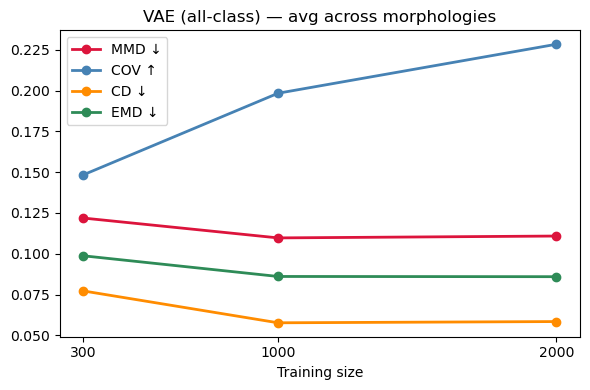

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["vae_300", "vae_1000", "vae_2000"]
x = [300, 1000, 2000]

MMD = {"vae_300": [0.134011, 0.137366, 0.100142, 0.115992], "vae_1000": [0.133847, 0.105827, 0.090568, 0.108606], "vae_2000": [0.131822, 0.119639, 0.088111, 0.103838]}
COV = {"vae_300": [0.1400, 0.0400, 0.2200, 0.1933], "vae_1000": [0.1533, 0.0467, 0.3133, 0.2800], "vae_2000": [0.1600, 0.0533, 0.3800, 0.3200]}
CD  = {"vae_300": [0.093010, 0.063781, 0.049512, 0.102633], "vae_1000": [0.081412, 0.053742, 0.043027, 0.052667], "vae_2000": [0.085000, 0.052617, 0.042047, 0.054214]}
EMD = {"vae_300": [0.123969, 0.082344, 0.074697, 0.114021], "vae_1000": [0.125283, 0.086772, 0.059544, 0.072763], "vae_2000": [0.125498, 0.089502, 0.054914, 0.073914]}

avg = lambda d: [np.mean(d[m]) for m in models]

fig, ax = plt.subplots(figsize=(12, 4))

for data, label, color in [
    (MMD, "MMD ↓", "crimson"),
    (COV, "COV ↑", "steelblue"),
    (CD,  "CD ↓",  "darkorange"),
    (EMD, "EMD ↓", "seagreen"),
]:
    ax.plot(x, avg(data), marker="o", linewidth=2, label=label, color=color)

ax.set_xticks(x)
ax.set_xticklabels(["300", "1000", "2000"])
ax.set_xlabel("Training size")
ax.set_title("VAE (all-class) — avg across morphologies")
ax.legend()
plt.tight_layout()
plt.show()
